# EDA — `lexdata.ivf_municipios`
Índice de Vulnerabilidad Familiar · tabla de scoring por municipio

## 0 · Setup

In [1]:
# ── Dependencias ────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

# ── Estilo ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ── Conexión PostgreSQL via .env ─────────────────────────────────────────────
load_dotenv()  # carga .env desde la carpeta del notebook
DB_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
engine = create_engine(DB_URL)

def sql(query, **kwargs):
    with engine.connect() as con:
        return pd.read_sql(text(query), con, **kwargs)

print("✅ Conexión lista:", DB_URL.split("@")[-1])


✅ Conexión lista: localhost:5432/lexdata


## 1 · Vista general

In [2]:
df = sql("SELECT * FROM lexdata.ivf_municipios")
print(f"Shape: {df.shape}")
print(f"Municipios únicos : {df['municipio'].nunique()}")
print(f"Años disponibles  : {sorted(df['anio'].dropna().unique().tolist())}")
print(f"Municipios en alerta: {df['alerta'].sum()} ({df['alerta'].mean()*100:.1f} %)")
df.head()


Shape: (1061, 14)
Municipios únicos : 1061
Años disponibles  : []
Municipios en alerta: 275 (25.9 %)


,id,municipio,anio,vif_total,alimentos_familia_total,medidas_proteccion_total,inasistencia_total,ivf_score_bruto,ivf_score_ponderado,ivf_tasa_100k,nivel_riesgo,poblacion,alerta,created_at
0,1063,SIN_DATO,None,0.0,114650.0,0.0,0.0,34395.0,91.916667,11465.00,None,None,True,2026-05-25 14:23:14.708669
1,1064,"BOGOTA, D.C.",None,25842.0,0.0,0.0,0.0,10336.8,33.140000,4134.72,None,None,True,2026-05-25 14:23:14.708669
2,1065,BOGOTA D.C. (CT),None,11658.0,0.0,0.0,0.0,4663.2,12.483333,1554.40,None,None,True,2026-05-25 14:23:14.708669
3,1066,MEDELLIN,None,6398.0,0.0,0.0,0.0,2559.2,8.200000,1023.68,None,None,True,2026-05-25 14:23:14.708669
4,1067,SOACHA,None,6651.0,0.0,0.0,0.0,2660.4,7.100000,886.80,None,None,True,2026-05-25 14:23:14.708669


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,1061.0,NaN,NaN,NaN,1593.0,1063.0,1328.0,1593.0,1858.0,2123.0,306.428621
municipio,1061,1061,ALTAMIRA,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anio,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vif_total,1061.0,NaN,NaN,NaN,284.526861,0.0,30.0,71.0,177.0,25842.0,1043.914595
alimentos_familia_total,1061.0,NaN,NaN,NaN,108.058435,0.0,0.0,0.0,0.0,114650.0,3519.786872
medidas_proteccion_total,1061.0,NaN,NaN,NaN,0.05278,0.0,0.0,0.0,0.0,2.0,0.227878
inasistencia_total,1061.0,NaN,NaN,NaN,0.05278,0.0,0.0,0.0,0.0,2.0,0.227878
ivf_score_bruto,1061.0,NaN,NaN,NaN,146.244109,0.4,12.4,28.4,71.2,34395.0,1132.242807
ivf_score_ponderado,1061.0,NaN,NaN,NaN,0.393417,0.0,0.016667,0.066667,0.183333,91.916667,3.08318
ivf_tasa_100k,1061.0,NaN,NaN,NaN,49.714748,0.7,4.32,9.6,25.066667,11465.0,384.034168


## 2 · Nulos

In [4]:
nulos = df.isnull().sum().rename("nulos")
pct   = (df.isnull().mean() * 100).round(2).rename("pct_%")
display(pd.concat([nulos, pct], axis=1).query("nulos > 0"))


,nulos,pct_%
anio,1061,100.0
nivel_riesgo,1061,100.0
poblacion,1061,100.0


## 3 · Distribución IVF Score Ponderado

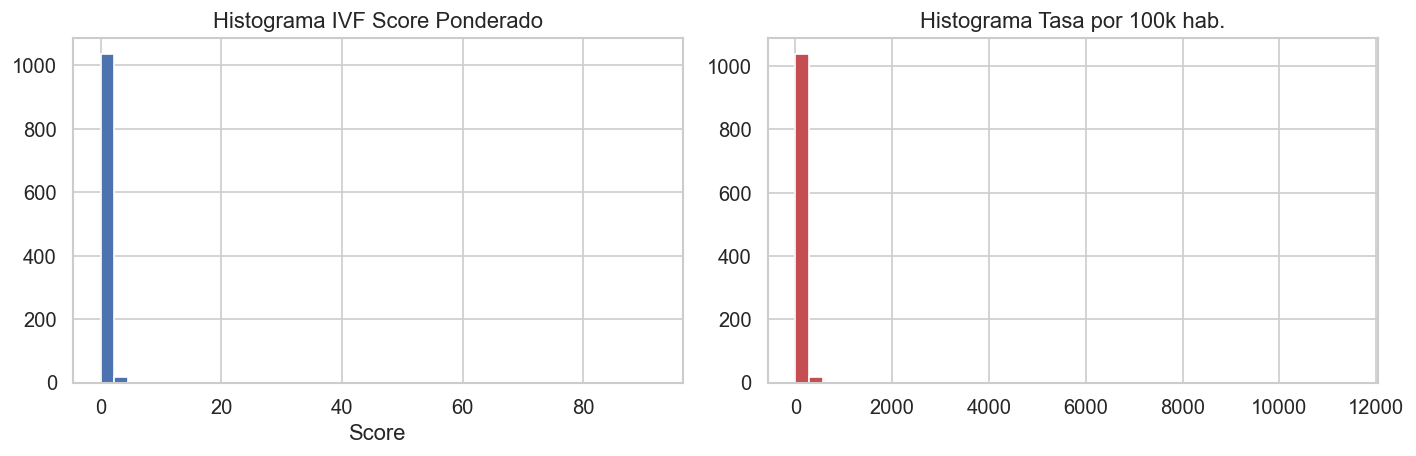

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["ivf_score_ponderado"].dropna().hist(bins=40, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Histograma IVF Score Ponderado")
axes[0].set_xlabel("Score")

df["ivf_tasa_100k"].dropna().hist(bins=40, ax=axes[1], color="#C44E52", edgecolor="white")
axes[1].set_title("Histograma Tasa por 100k hab.")

plt.tight_layout(); plt.show()


## 4 · Correlación entre dimensiones IVF

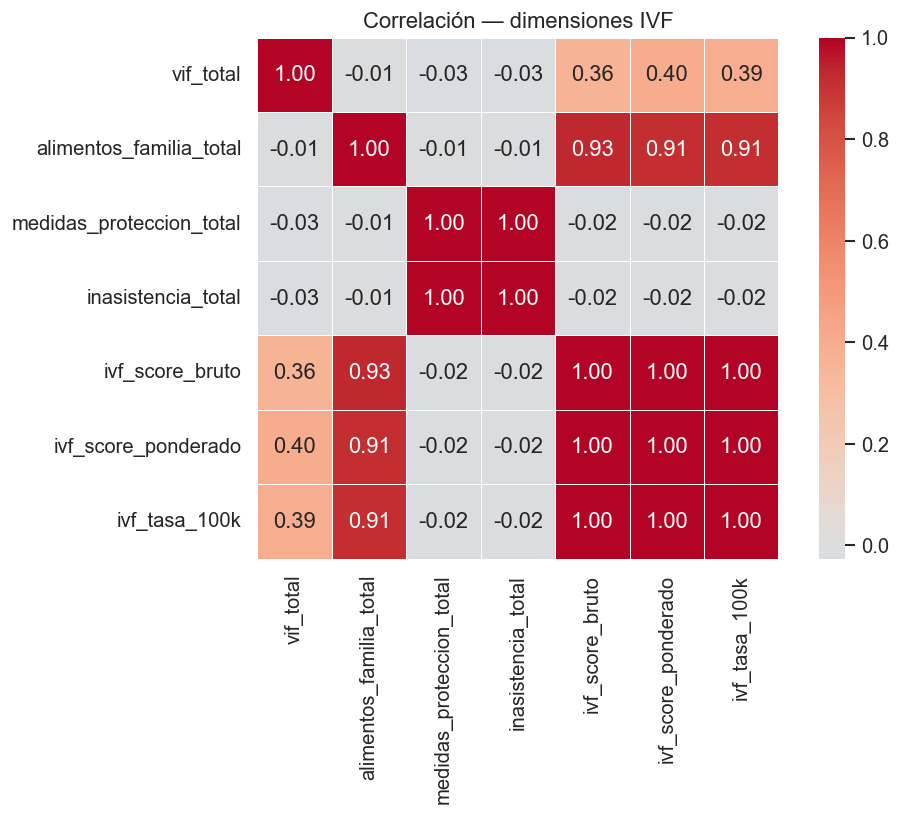

In [6]:
dims = ["vif_total", "alimentos_familia_total", "medidas_proteccion_total",
        "inasistencia_total", "ivf_score_bruto", "ivf_score_ponderado", "ivf_tasa_100k"]
corr = df[dims].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlación — dimensiones IVF")
plt.tight_layout(); plt.show()


## 6 · Top 20 municipios por IVF Score Ponderado

In [8]:
top = df.nlargest(20, "ivf_score_ponderado")[
    ["municipio", "anio", "ivf_score_ponderado", "ivf_tasa_100k", "nivel_riesgo", "alerta"]
]
display(top.reset_index(drop=True))


,municipio,anio,ivf_score_ponderado,ivf_tasa_100k,nivel_riesgo,alerta
0,SIN_DATO,None,91.916667,11465.000000,None,True
1,"BOGOTA, D.C.",None,33.140000,4134.720000,None,True
2,BOGOTA D.C. (CT),None,12.483333,1554.400000,None,True
3,MEDELLIN,None,8.200000,1023.680000,None,True
4,SOACHA,None,7.100000,886.800000,None,True
5,MEDELLIN (CT),None,6.500000,809.200000,None,True
6,CALI (CT),None,5.133333,639.600000,None,True
7,CALI,None,4.160000,11.608000,None,True
8,CARTAGENA (CT),None,3.983333,498.666667,None,True
9,BELLO,None,3.866667,482.800000,None,True


## 8 · Municipios en alerta — scatter tasa vs score

C:\Users\Acer\AppData\Local\Temp\ipykernel_20192\1328083924.py:14: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\Acer\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


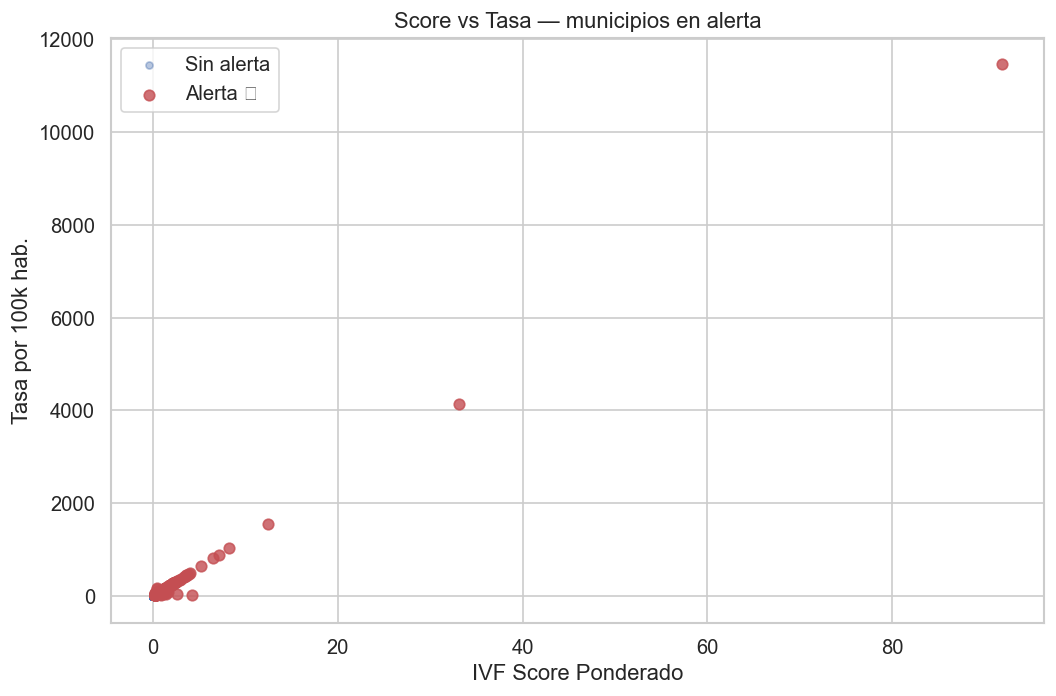

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
no_alerta = df[df["alerta"] == False]
si_alerta  = df[df["alerta"] == True]

ax.scatter(no_alerta["ivf_score_ponderado"], no_alerta["ivf_tasa_100k"],
           alpha=0.4, s=18, color="#4C72B0", label="Sin alerta")
ax.scatter(si_alerta["ivf_score_ponderado"], si_alerta["ivf_tasa_100k"],
           alpha=0.8, s=40, color="#C44E52", label="Alerta ⚠")

ax.set_xlabel("IVF Score Ponderado")
ax.set_ylabel("Tasa por 100k hab.")
ax.set_title("Score vs Tasa — municipios en alerta")
ax.legend()
plt.tight_layout(); plt.show()


## 9 · Exportar municipios en alerta